In [1]:
from datetime import datetime
import numpy as np

from IPython.display import Image, display
import ROOT

In [2]:
datafilename = './data_histos.root'
datafile = ROOT.TFile(datafilename)

In [31]:
# Intialise the files
filenameslist = ['./hists/hist_3cm.root', './hists/hist_30cm.root', './hists/hist_1m.root', './hists/hist_3m.root']
open_infiles = [ROOT.TFile.Open(filename) for filename in filenameslist]

def plotmc(var, binedges, *, logy=False, logx=False, normalise=False):
    # Create a canvas
    now_str = datetime.now().strftime("%Y_%m_%d_%H_%M_%S")
    binedges = np.array(binedges, dtype=np.float64)

    c = ROOT.TCanvas("c"+now_str, "c"+now_str, 800, 600)
    ROOT.gStyle.SetOptStat(0)
    if logy:
        c.SetLogy()
    if logx:
        c.SetLogx()
    legend = ROOT.TLegend(0.7, 0.7, 0.9, 0.9)

    varhists = [file.Get(var) for file in open_infiles]

    for i, hist in enumerate(varhists):
        newhist = hist.Rebin(len(binedges)-1, var+'_rebinned', binedges)

        newhist.SetLineColor(i+2)
        newhist.SetLineWidth(2)

        if normalise:
            newhist.Scale(1.0 / newhist.Integral())
            
        if not normalise and logy:
            newhist.SetMinimum(1)

        newhist.Draw("HIST SAME E1")

        legend.AddEntry(newhist, filenameslist[i], "l")

    legend.Draw()
    c.Update()

    plotname = f"plots/{var}_{now_str}.png"
    c.SaveAs(plotname)
    return plotname       

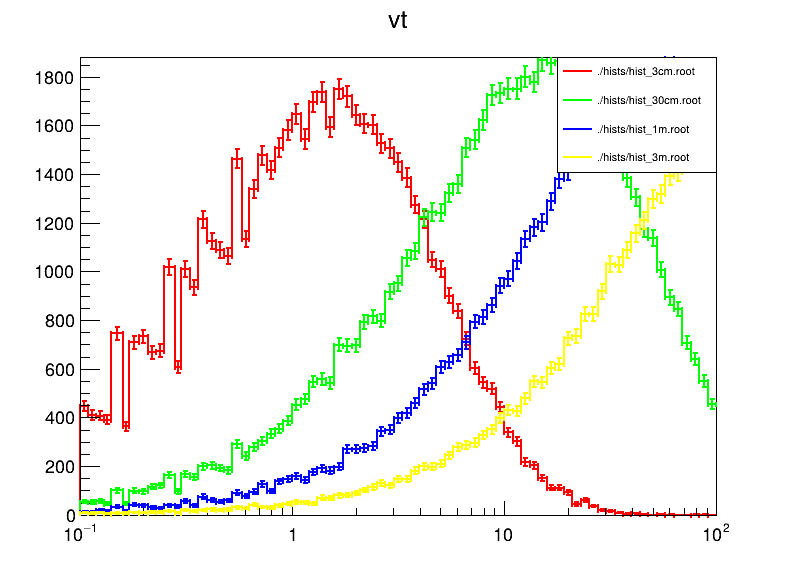

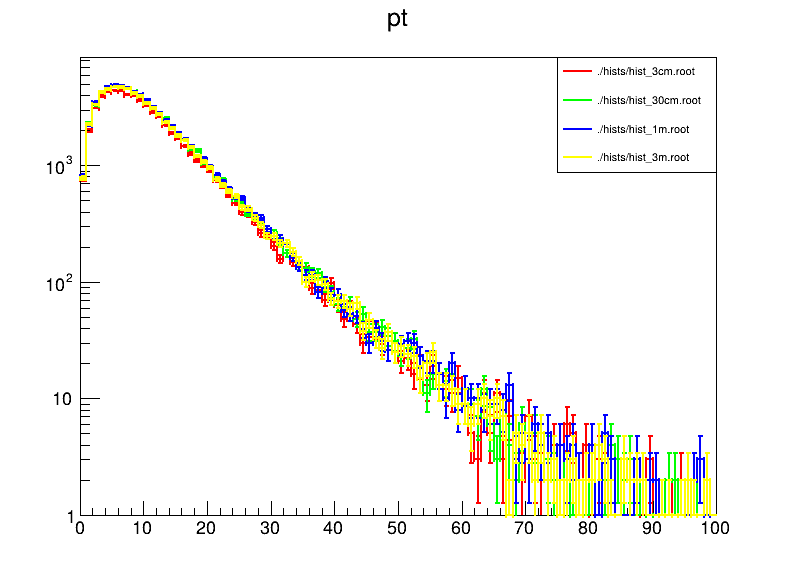

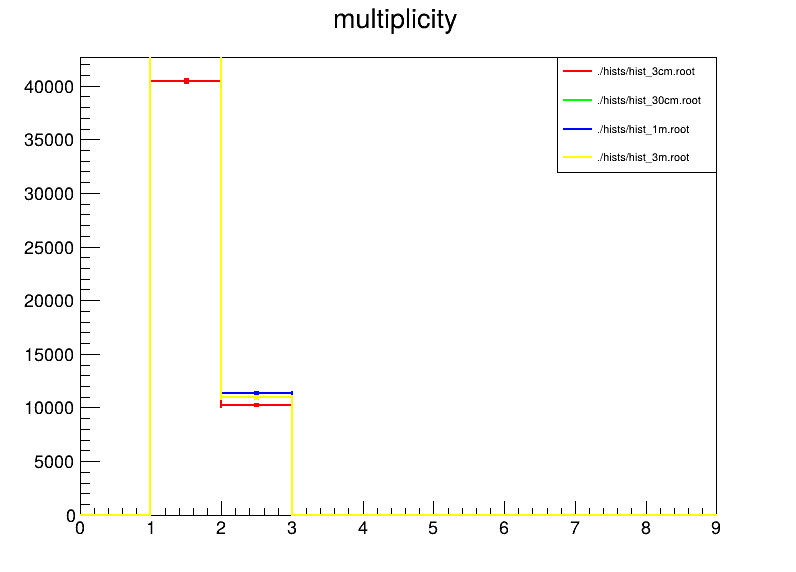

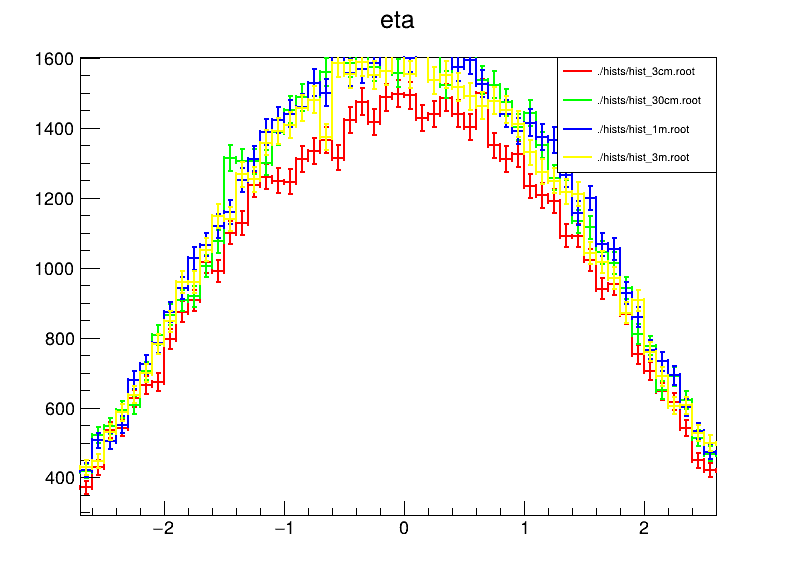

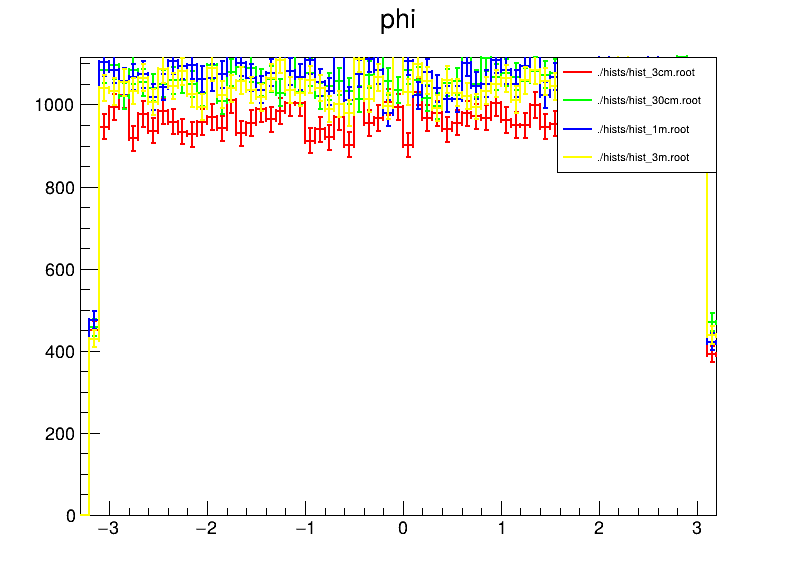

Info in <TCanvas::Print>: png file plots/vt_e_2025_04_25_13_37_03.png has been created
Info in <TCanvas::Print>: png file plots/pt_e_2025_04_25_13_37_03.png has been created
Info in <TCanvas::Print>: png file plots/n_e_2025_04_25_13_37_03.png has been created
Info in <TCanvas::Print>: png file plots/eta_e_2025_04_25_13_37_03.png has been created
Info in <TCanvas::Print>: png file plots/phi_e_2025_04_25_13_37_03.png has been created


In [22]:
vte = plotmc('vt_e', np.round(10**np.arange(-1, 2.04, 0.04), 2), logx=True)
pte = plotmc('pt_e', np.arange(0, 101, 1), logy=True)
ne = plotmc('n_e', np.arange(0, 10, 1))
etae = plotmc('eta_e', np.arange(-2.7, 2.7, 0.1))
phie = plotmc('phi_e', np.arange(-3.3, 3.3, 0.1))
display(Image(filename=vte), Image(filename=pte), Image(filename=ne), Image(filename=etae), Image(filename=phie))

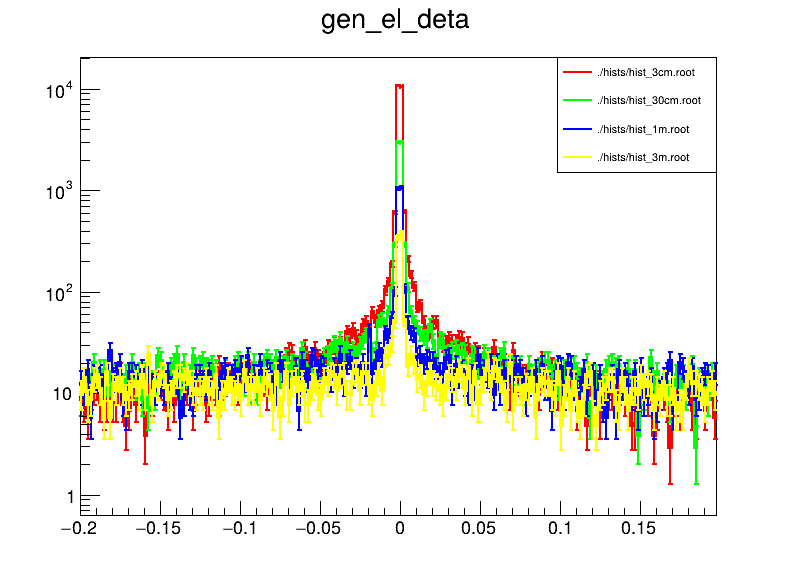

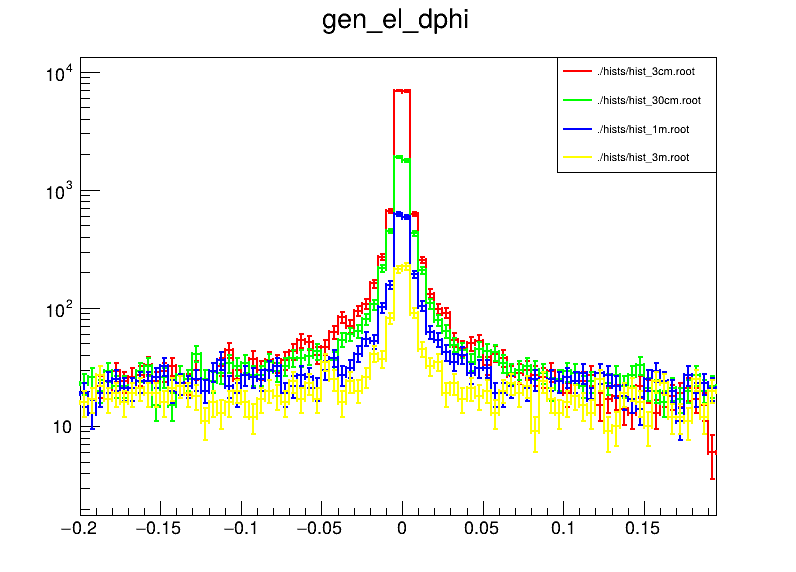

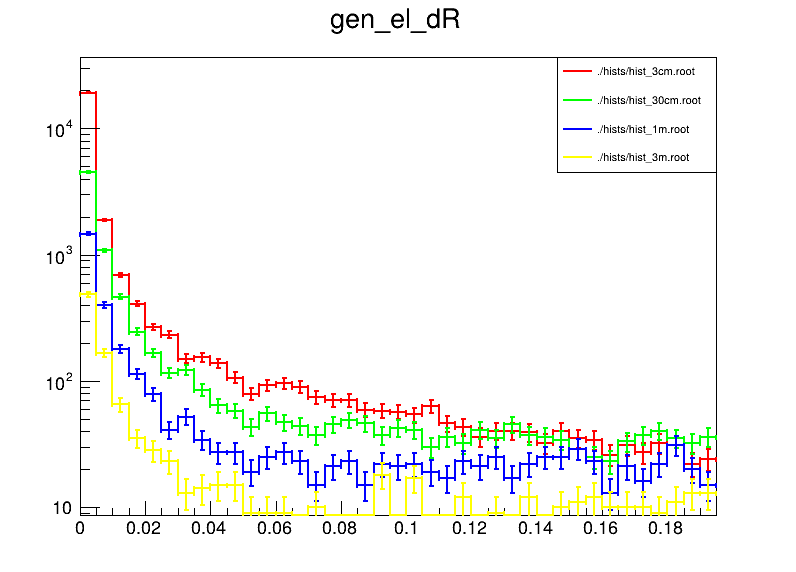

Info in <TCanvas::Print>: png file plots/gen_el_deta_2025_04_25_12_21_50.png has been created
Info in <TCanvas::Print>: png file plots/gen_el_dphi_2025_04_25_12_21_50.png has been created
Info in <TCanvas::Print>: png file plots/gen_el_dR_2025_04_25_12_21_50.png has been created


In [5]:
detae = plotmc('gen_el_deta', np.arange(-0.2, 0.2, 0.002), logy=True)
dphie = plotmc('gen_el_dphi', np.arange(-0.2, 0.2, 0.005), logy=True)
dRe = plotmc('gen_el_dR', np.arange(0, 0.2, 0.005), logy=True)
display(Image(filename=detae), Image(filename=dphie), Image(filename=dRe))

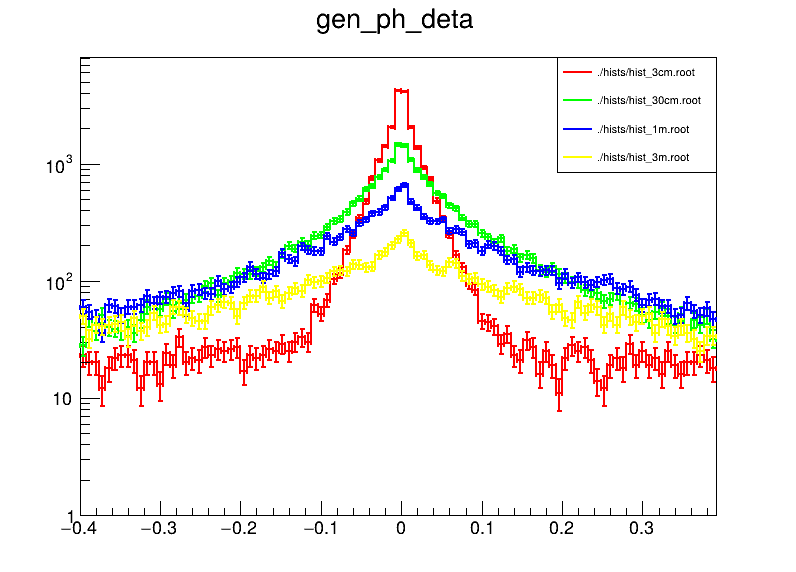

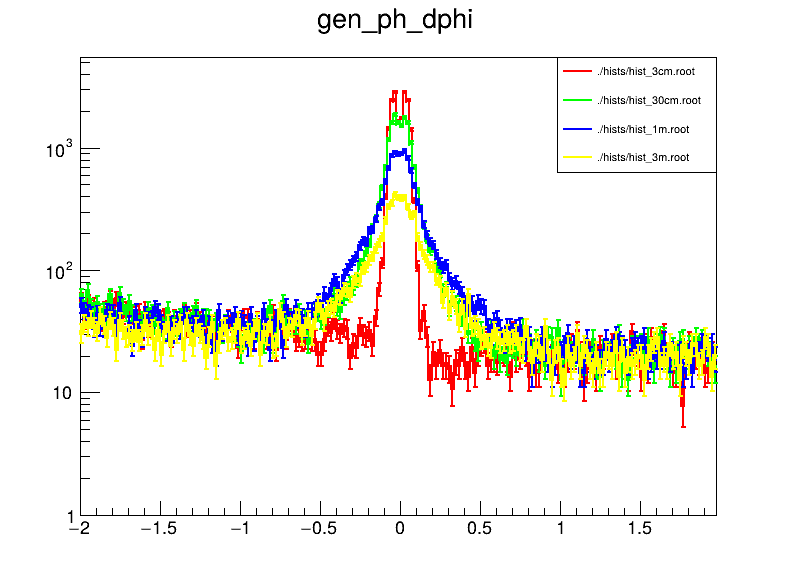

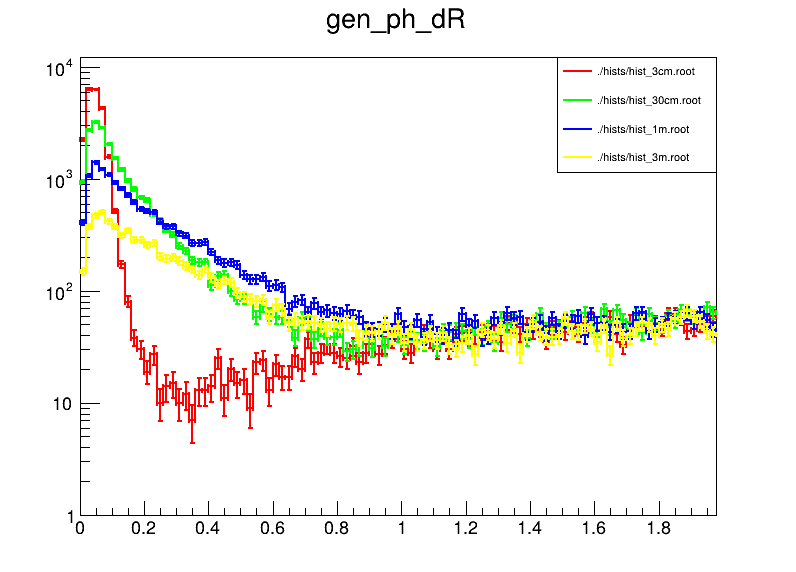

Info in <TCanvas::Print>: png file plots/gen_ph_deta_2025_04_25_14_09_43.png has been created
Info in <TCanvas::Print>: png file plots/gen_ph_dphi_2025_04_25_14_09_43.png has been created
Info in <TCanvas::Print>: png file plots/gen_ph_dR_2025_04_25_14_09_43.png has been created


In [36]:
detae = plotmc('gen_ph_deta', np.arange(-0.4, 0.4, 0.008), logy=True)
dphie = plotmc('gen_ph_dphi', np.arange(-2, 2, 0.02), logy=True)
dRe = plotmc('gen_ph_dR', np.arange(0, 2, 0.02), logy=True)
display(Image(filename=detae), Image(filename=dphie), Image(filename=dRe))

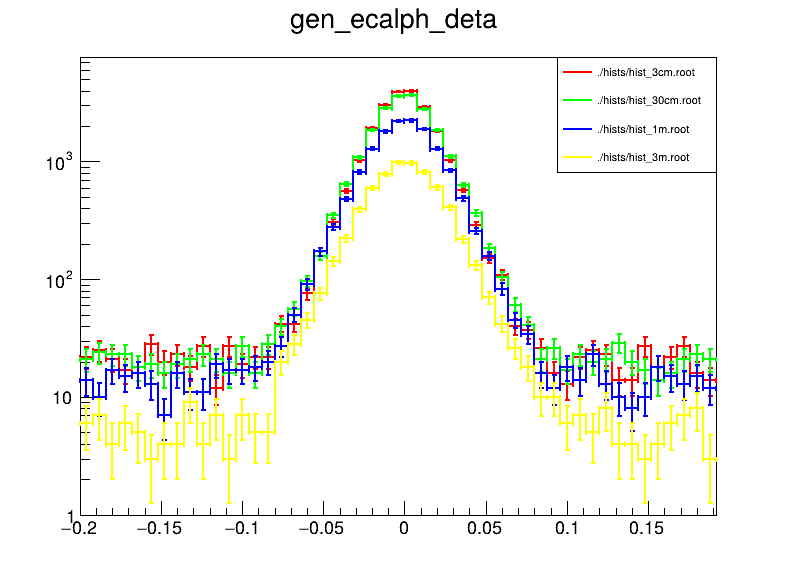

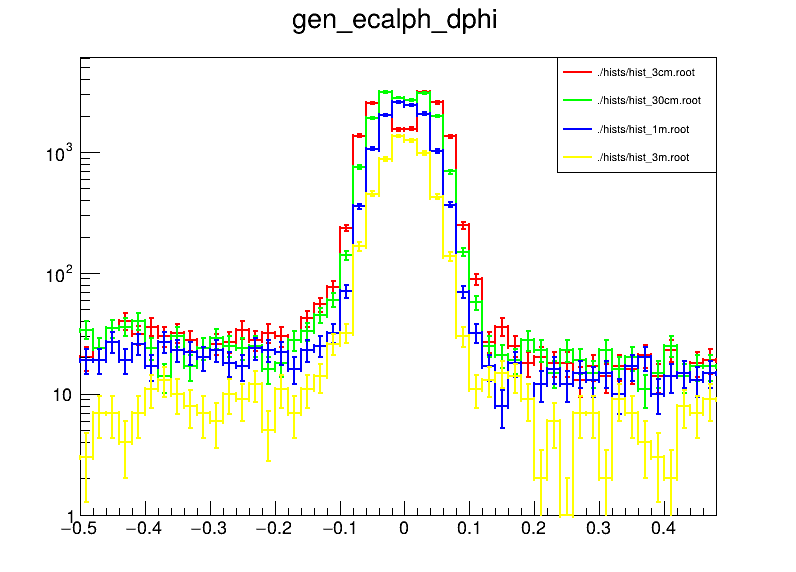

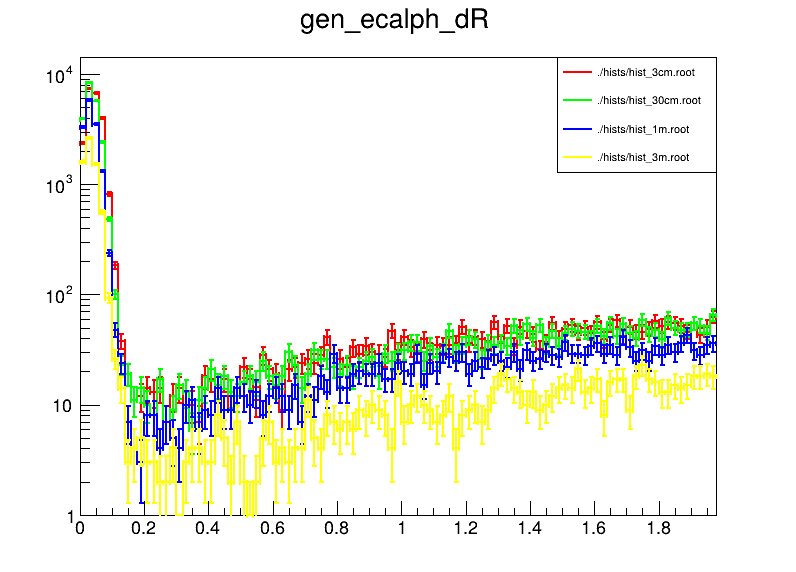

Info in <TCanvas::Print>: png file plots/gen_ecalph_deta_2025_04_25_14_10_28.png has been created
Info in <TCanvas::Print>: png file plots/gen_ecalph_dphi_2025_04_25_14_10_28.png has been created
Info in <TCanvas::Print>: png file plots/gen_ecalph_dR_2025_04_25_14_10_28.png has been created


In [38]:
detae = plotmc('gen_ecalph_deta', np.arange(-0.2, 0.2, 0.008), logy=True)
dphie = plotmc('gen_ecalph_dphi', np.arange(-0.5, 0.5, 0.02), logy=True)
dRe = plotmc('gen_ecalph_dR', np.arange(0, 2, 0.02), logy=True)
display(Image(filename=detae), Image(filename=dphie), Image(filename=dRe))

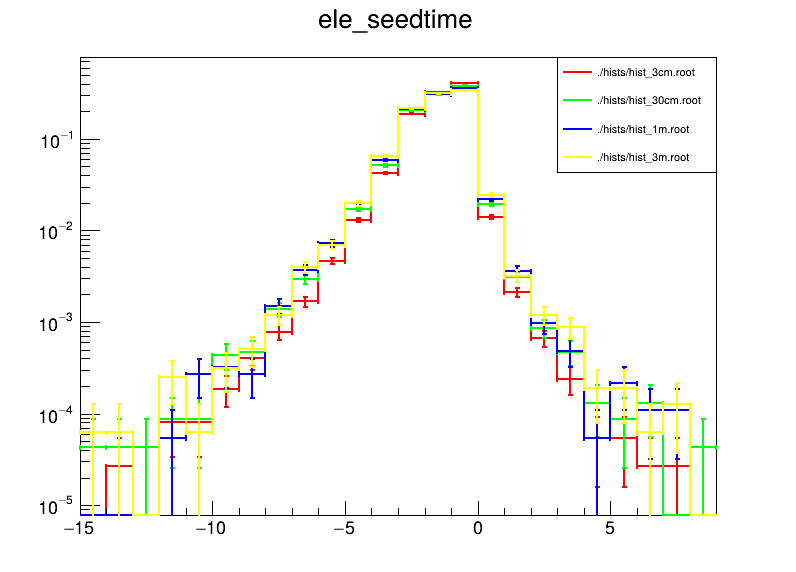

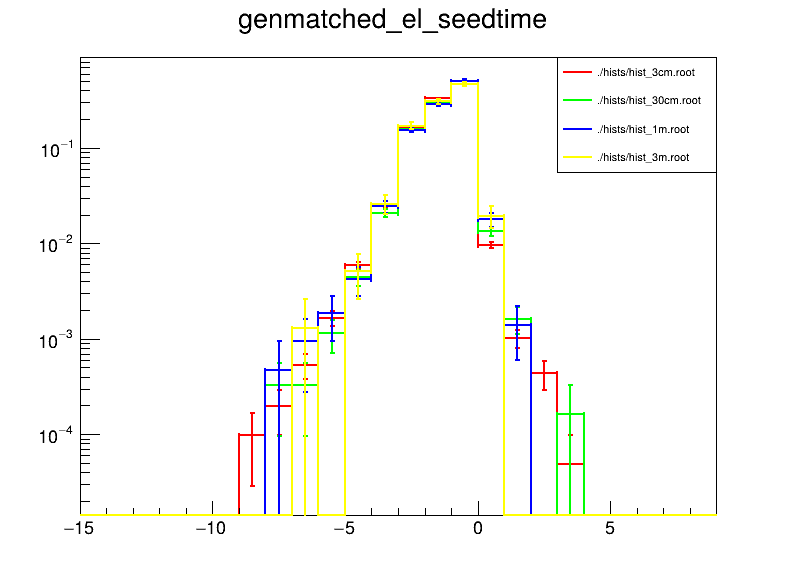

Info in <TCanvas::Print>: png file plots/ele_seedtime_2025_04_25_12_21_52.png has been created
Info in <TCanvas::Print>: png file plots/genmatched_el_seedtime_2025_04_25_12_21_52.png has been created


In [8]:
sdtime = plotmc('ele_seedtime', np.arange(-15, 10, 1), logy=True, normalise=True)
gmatched_sdtime = plotmc('genmatched_el_seedtime', np.arange(-15, 10, 1), logy=True, normalise=True)
display(Image(filename=sdtime), Image(filename=gmatched_sdtime))

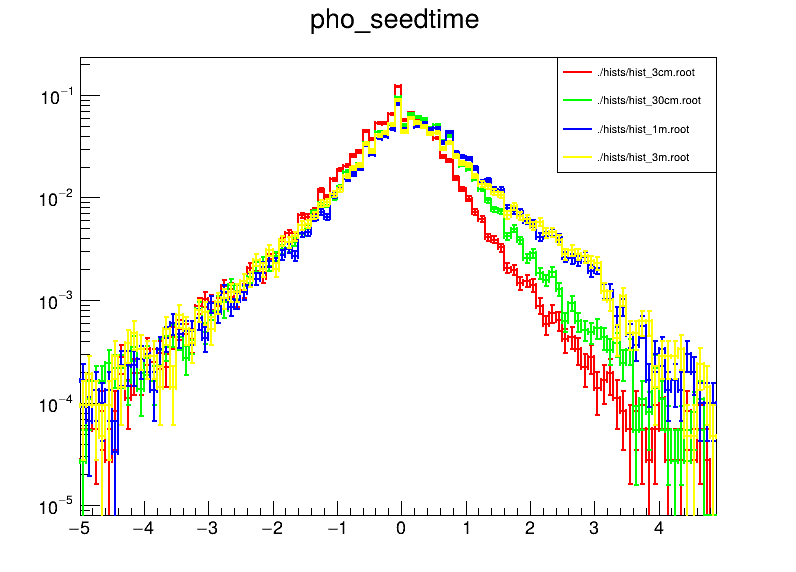

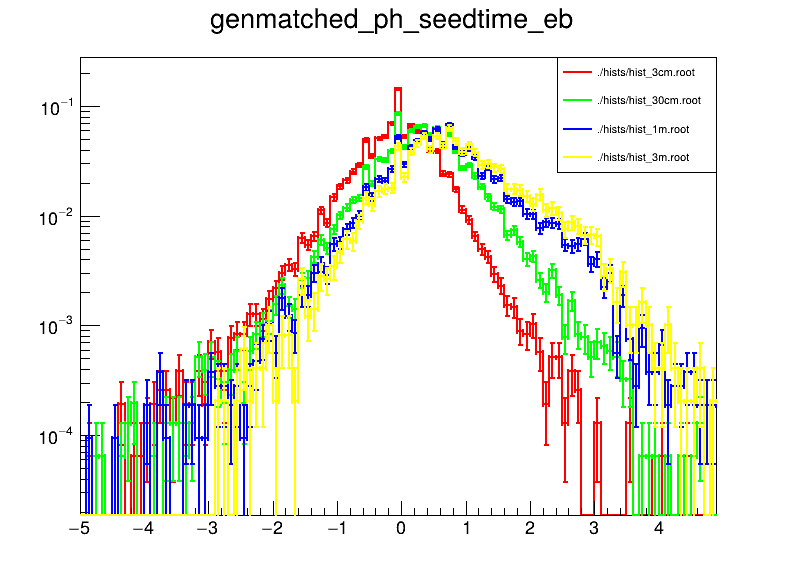

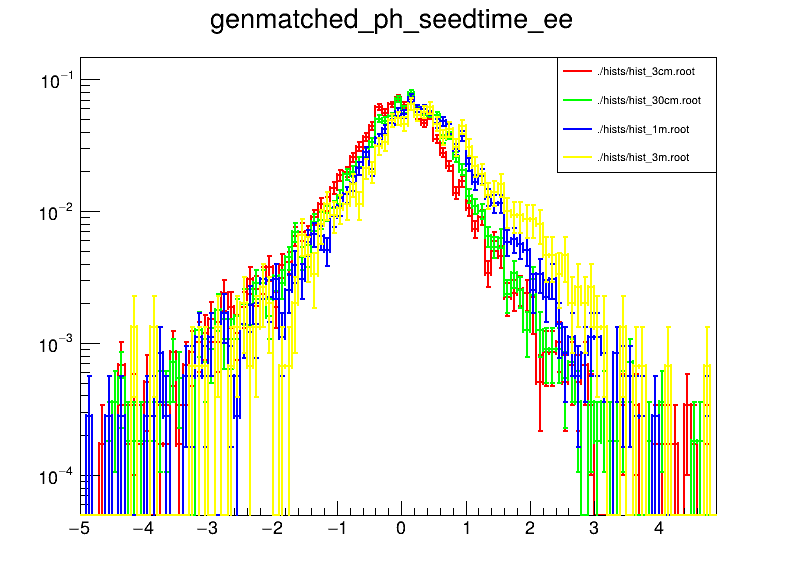

Info in <TCanvas::Print>: png file plots/pho_seedtime_2025_04_25_12_21_53.png has been created
Info in <TCanvas::Print>: png file plots/genmatched_ph_seedtime_eb_2025_04_25_12_21_53.png has been created
Info in <TCanvas::Print>: png file plots/genmatched_ph_seedtime_ee_2025_04_25_12_21_53.png has been created


In [9]:
sdtime = plotmc('pho_seedtime', np.arange(-5, 5, 0.1), logy=True, normalise=True)
gmatched_sdtime_eb = plotmc('genmatched_ph_seedtime_eb', np.arange(-5, 5, 0.1), logy=True, normalise=True)
gmatched_sdtime_ee = plotmc('genmatched_ph_seedtime_ee', np.arange(-5, 5, 0.1), logy=True, normalise=True)
display(Image(filename=sdtime), Image(filename=gmatched_sdtime_eb), Image(filename=gmatched_sdtime_ee))

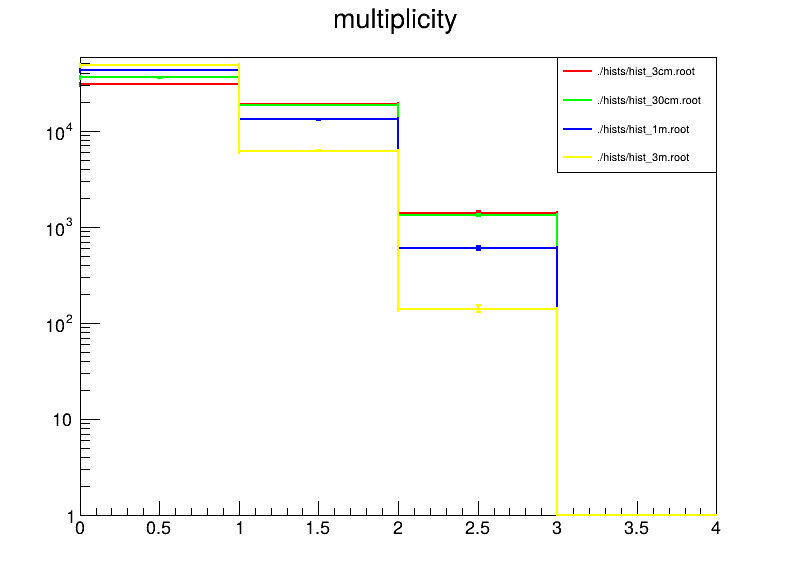

Info in <TCanvas::Print>: png file plots/recomatched_gene_n_2025_04_25_13_37_07.png has been created


In [23]:
ne = plotmc('recomatched_gene_n', np.arange(0, 5, 1), logy=True)
display(Image(filename=ne))

In [25]:
# Make trigger efficiency plots

def plotmc_trigger(refvar, targetvar, binedges, *, logx=False):
    # Create a canvas
    now_str = datetime.now().strftime("%Y_%m_%d_%H_%M_%S")
    binedges = np.array(binedges, dtype=np.float64)

    c = ROOT.TCanvas("c"+now_str, "c"+now_str, 800, 1200)
    ROOT.gStyle.SetOptStat(0)
    c.Divide(2, 4)

    refvarhists = [file.Get(refvar) for file in open_infiles]
    targetvarhists = [file.Get(targetvar) for file in open_infiles]
    plot_eff = [None]*len(refvarhists)

    for i, _ in enumerate(refvarhists):
        if i > 3: 
            break
        c.cd(2*i+1)
        ROOT.gPad.SetLogy()
        if logx:
            ROOT.gPad.SetLogx()
        
        newrefvarhist = refvarhists[i].Rebin(len(binedges)-1, refvar+'_rebinned', binedges)
        newtargetvarhist = targetvarhists[i].Rebin(len(binedges)-1, targetvar+'_rebinned', binedges)

        newrefvarhist.SetLineColor(ROOT.kBlue)
        newrefvarhist.SetLineWidth(2)
        newtargetvarhist.SetLineColor(ROOT.kRed)
        newtargetvarhist.SetLineWidth(2)

        newrefvarhist.SetMinimum(1) 

        newrefvarhist.Draw("HIST SAME E1")
        newtargetvarhist.Draw("HIST SAME E1")

        c.cd(2*i+2)
        if logx:
            ROOT.gPad.SetLogx()
        

        plot_eff[i] = ROOT.TEfficiency(newtargetvarhist, newrefvarhist)

        plot_eff[i].SetLineWidth(2)

        plot_eff[i].Draw("AP")

        c.Update()

    plotname = f"plots/comapre_{targetvar}_{now_str}.png"
    c.SaveAs(plotname)
    return plotname   

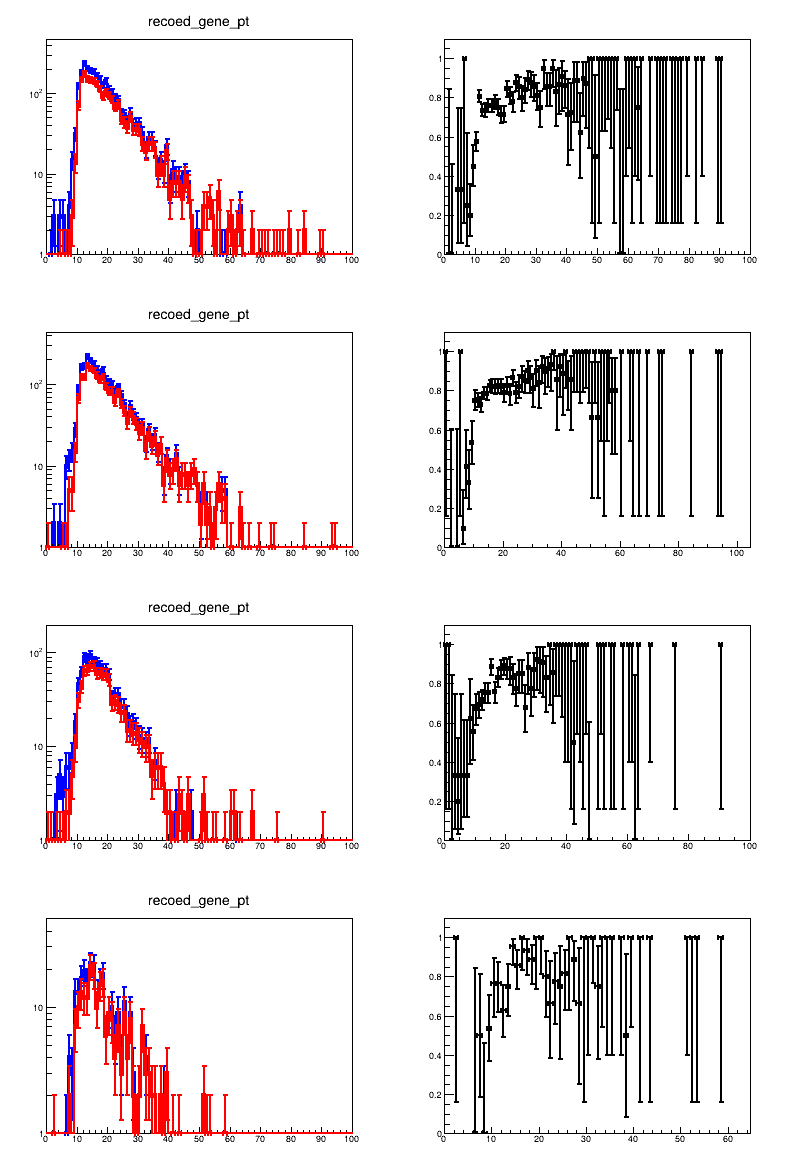

Info in <TCanvas::Print>: png file plots/comapre_hlt_gene_pt_2025_04_25_13_51_38.png has been created


In [32]:
trigpte = plotmc_trigger('recoed_gene_pt', 'hlt_gene_pt', np.arange(0, 101, 1))
display(Image(filename=trigpte))

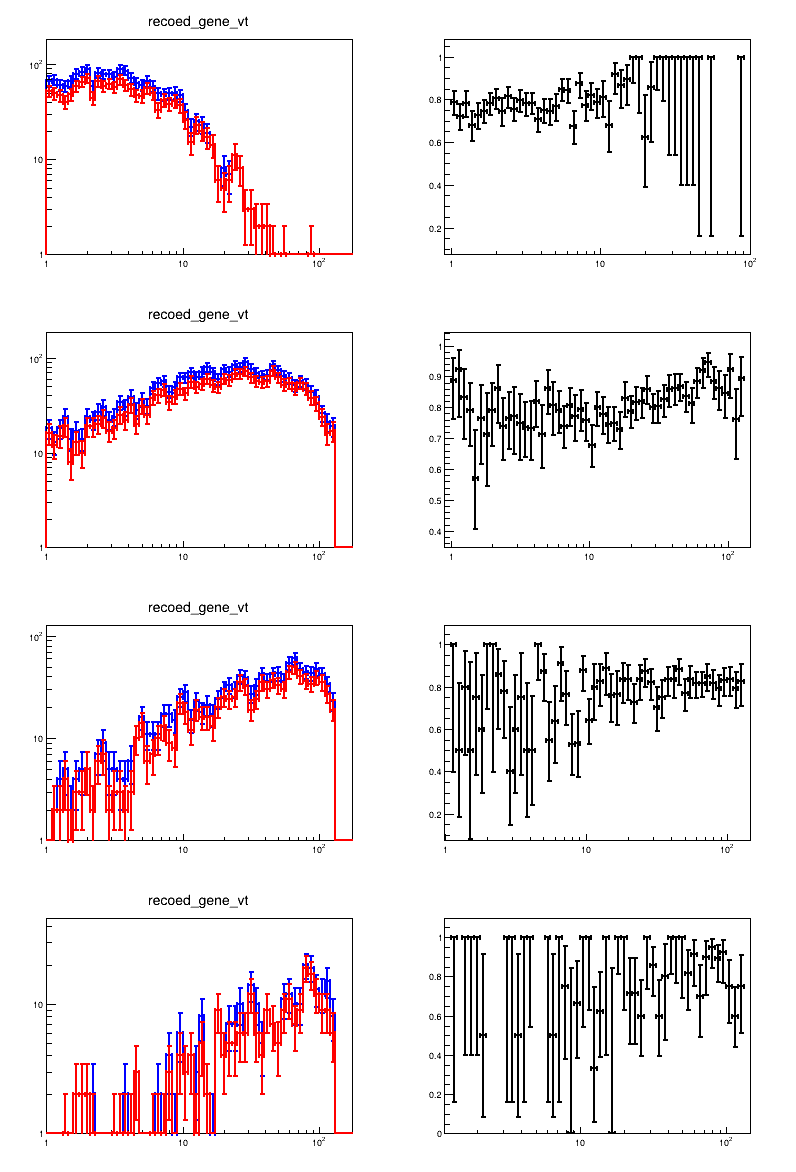

Info in <TCanvas::Print>: png file plots/comapre_hlt_gene_vt_2025_04_25_13_51_39.png has been created


In [33]:
trigvte = plotmc_trigger('recoed_gene_vt', 'hlt_gene_vt', np.round(10**np.arange(0, 2.28, 0.04), 2), logx=True)
display(Image(filename=trigvte))

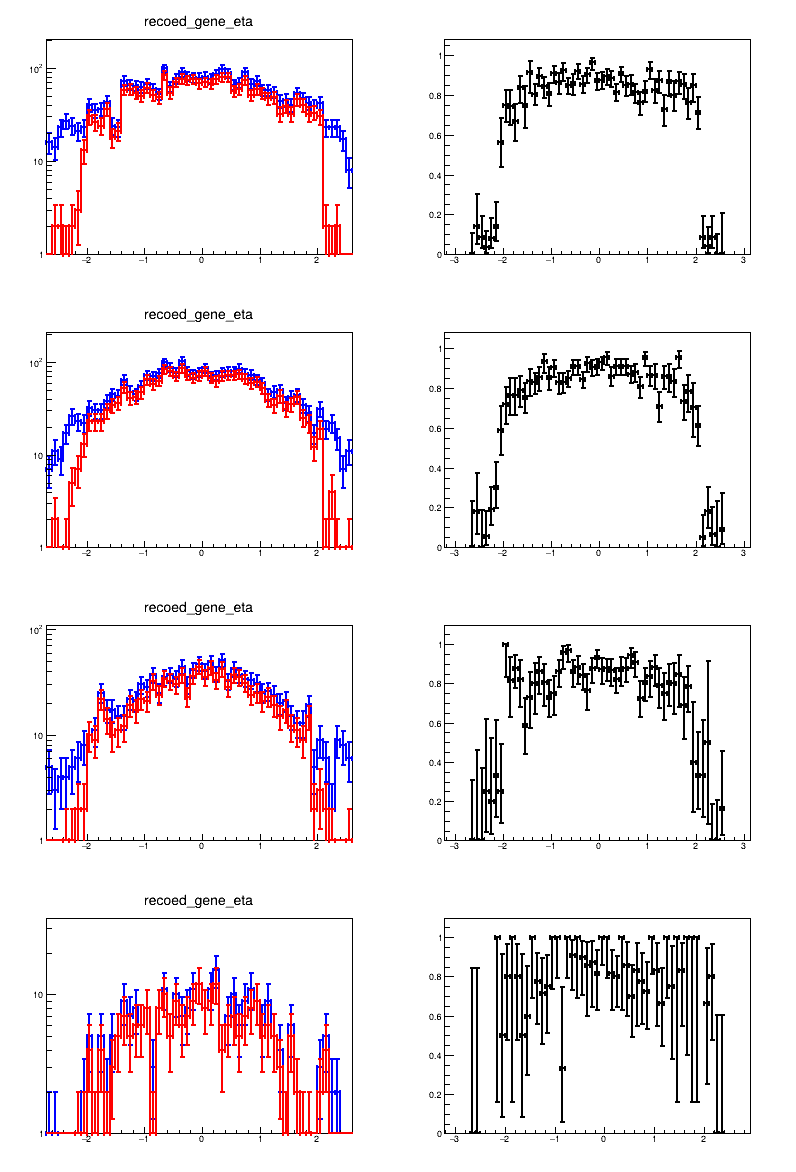

Info in <TCanvas::Print>: png file plots/comapre_hlt_gene_eta_2025_04_25_13_51_39.png has been created


In [34]:
trigetae = plotmc_trigger('recoed_gene_eta', 'hlt_gene_eta', np.arange(-2.7, 2.7, 0.1))
display(Image(filename=trigetae))

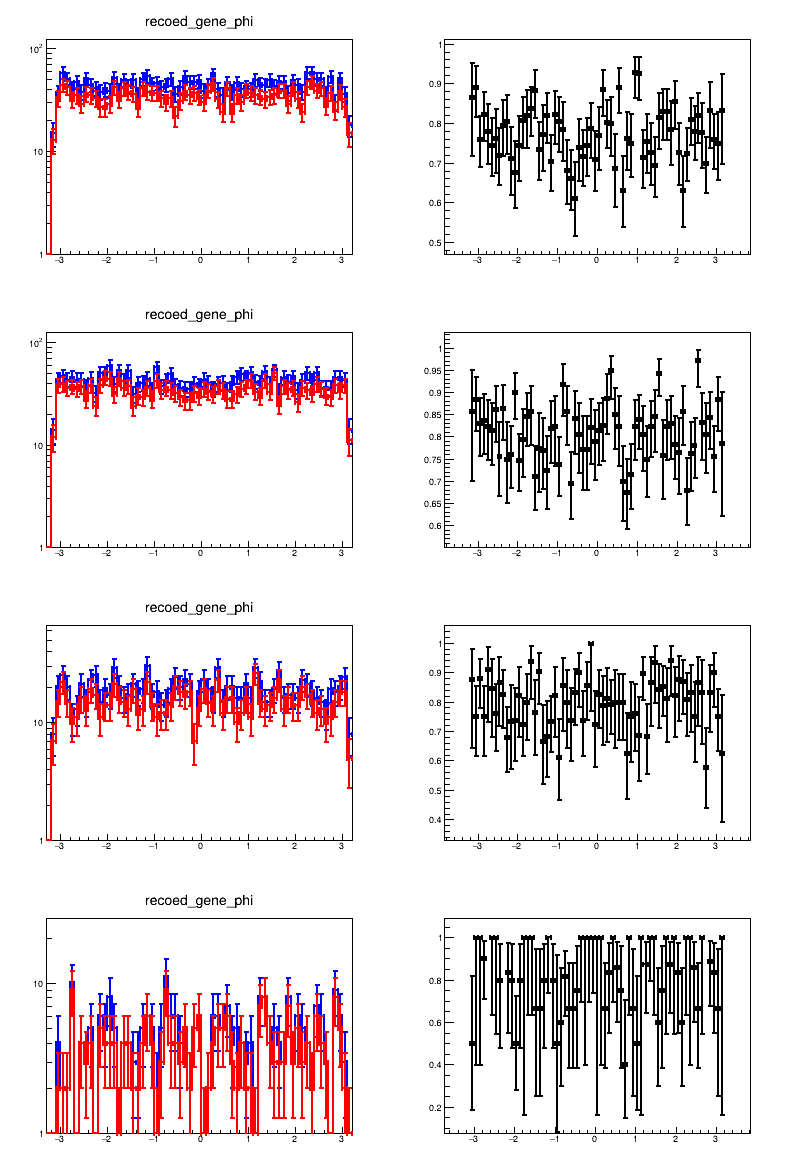

Info in <TCanvas::Print>: png file plots/comapre_hlt_gene_phi_2025_04_25_13_51_39.png has been created


In [35]:
trigphie = plotmc_trigger('recoed_gene_phi', 'hlt_gene_phi', np.arange(-3.3, 3.3, 0.1))
display(Image(filename=trigphie))